In [1]:
from os import path
from glob import glob

from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import mne

rawdir = '../data/raw/'

triggers = dict(
    S14='BN STD',
    S15='SN DEV',
    S24='SN STD',
    S25='BN DEV',
    S34='CN STD',
    S35='BN DEV',
)

%matplotlib widget

In [2]:
participants = pd.read_csv('participant_details.csv', index_col=0)
delays = participants['Tone_delay'].rename('tone delay')

In [3]:
# list all preprocessed files
# preprocessing involves manual curation, band pass filtering,
# down sampling, removal of eye artifacts, and epoching
files = glob(path.join(rawdir, 'preprocessed', '*'))
files

['../data/raw/preprocessed/sub-sd011-epo.fif',
 '../data/raw/preprocessed/sub-sd012-epo.fif',
 '../data/raw/preprocessed/sub-sd013-epo.fif',
 '../data/raw/preprocessed/sub-sd015-epo.fif',
 '../data/raw/preprocessed/sub-sd016-epo.fif',
 '../data/raw/preprocessed/sub-sd017-epo.fif',
 '../data/raw/preprocessed/sub-sd018-epo.fif',
 '../data/raw/preprocessed/sub-sd019-epo.fif',
 '../data/raw/preprocessed/sub-sd020-epo.fif',
 '../data/raw/preprocessed/sub-sd024_without_downsample-epo.fif',
 '../data/raw/preprocessed/sub-sd025-epo.fif',
 '../data/raw/preprocessed/sub-sd025_without_downsample-epo.fif',
 '../data/raw/preprocessed/sub-sd026-epo.fif',
 '../data/raw/preprocessed/sub-sd027-epo.fif',
 '../data/raw/preprocessed/sub-sd028-epo.fif',
 '../data/raw/preprocessed/sub-sd029-epo.fif',
 '../data/raw/preprocessed/sub-sd030-epo.fif',
 '../data/raw/preprocessed/sub-sd034-epo.fif',
 '../data/raw/preprocessed/sub-sd034_without_downsample-epo.fif',
 '../data/raw/preprocessed/sub-sd065-epo.fif',
 '.

# Manual check of delayed responses for delayed tones

In [165]:
# read epoched data for a 'normal' and a 'delayed' tone subject
data = {
    'FP_0.002': mne.read_epochs('../data/raw/preprocessed/sub-sd028-epo.fif'),
    'FP_0.007': mne.read_epochs('../data/raw/preprocessed/sub-sd025-epo.fif'),
    'FP_0.010': mne.read_epochs('../data/raw/preprocessed/sub-sd024_without_downsample-epo.fif'),
    'FP_0.030': mne.read_epochs('../data/raw/preprocessed/sub-sd020-epo.fif'),
    'FP_0.040': mne.read_epochs('../data/raw/preprocessed/sub-sd012-epo.fif'),
    'FP_0.040': mne.read_epochs('../data/raw/preprocessed/sub-sd016-epo.fif'),
    'FP_0.200': mne.read_epochs('../data/raw/preprocessed/sub-sd034-epo.fif'),
}

Reading /home/jupyter-saurabh/Github/ecf-exp2-notif-mmn/analysis/../data/raw/preprocessed/sub-sd028-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices available
Not setting metadata
1664 matching events found
No baseline correction applied
0 projection items activated
Reading /home/jupyter-saurabh/Github/ecf-exp2-notif-mmn/analysis/../data/raw/preprocessed/sub-sd025-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices available
Not setting metadata
1694 matching events found
No baseline correction applied
0 projection items activated
Reading /home/jupyter-saurabh/Github/ecf-exp2-notif-mmn/analysis/../data/raw/preprocessed/sub-sd024_without_downsample-epo.fif ...
    Found the data of interest:
        t =    -300.00 ...     900.00 ms
        0 CTF compensation matrices available
Not setting metadata
1023 matching events found
No baseline correction a

In [166]:
# compute average evoked response to different stimuli
# independent of the trial kind (STD or DEV) to get the stimulus-specific response
erps_ave, erps_sem = {}, {}
for cond, epochs in data.items():
    epochs = epochs.apply_baseline().to_data_frame()
    epochs[['stim', 'kind']] = epochs.condition.map(triggers).str.split(' ', expand=True)
    epochs = epochs.drop('condition', axis=1)
    erps_ave[cond] = epochs.drop(['epoch', 'kind'], axis=1).groupby(['stim', 'time']).mean()
    erps_sem[cond] = epochs.drop(['epoch', 'kind'], axis=1).groupby(['stim', 'time']).sem()
erps_ave = pd.concat(erps_ave, names=['tone'])
erps_sem = pd.concat(erps_sem, names=['tone'])
erps = pd.concat(dict(ave=erps_ave, sem=erps_sem))

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


In [167]:
erps_std = erps_ave.loc[:, :, -0.3:0.15].groupby(['tone', 'stim']).std()
erps_bsl = erps_ave.loc[:, :, -0.3:0.15].groupby(['tone', 'stim']).mean()

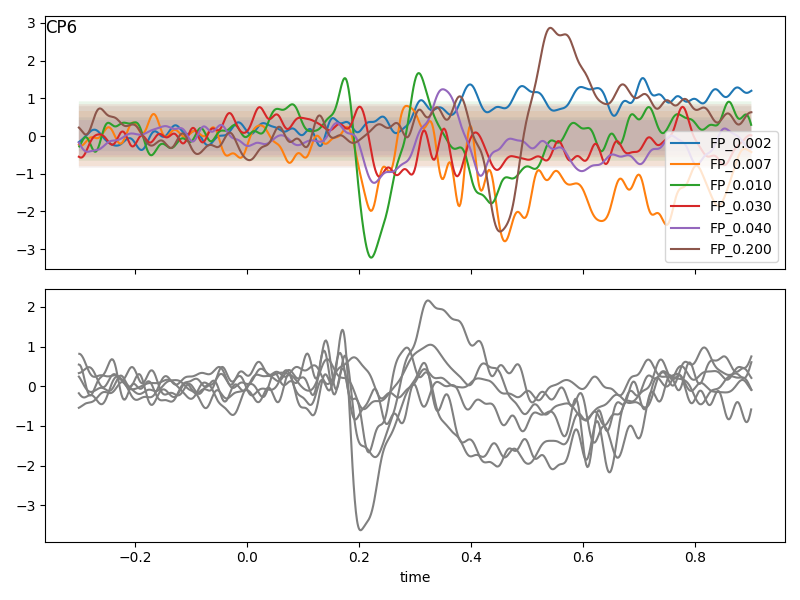

In [168]:
electrode = 'CP6'

f, (ax, ax2) = plt.subplots(2, 1, figsize=(8, 6), tight_layout=True, sharex=True)

erps_ave.xs('BN', level='stim')[electrode].groupby(['tone']).apply(
    lambda s: s.droplevel([0]).plot(ax=ax2, label='_', c='gray')
)
erps_ave.xs('SN', level='stim')[electrode].groupby(['tone']).apply(
    lambda s: s.droplevel([0]).plot(ax=ax, label=s.name)#, yerr=erps_std.loc[s.name, 'SN'][electrode])
)

# plot style 1
ax.set_prop_cycle(plt.rcParams['axes.prop_cycle'])
for stim in erps_std.index.levels[0]:
    ax.fill_between(
        erps_ave.groupby('time').mean().index,
        erps_bsl.loc[(stim, 'SN')][electrode] - erps_std.loc[(stim, 'SN')][electrode]*2.5,
        erps_bsl.loc[(stim, 'SN')][electrode] + erps_std.loc[(stim, 'SN')][electrode]*2.5,
        alpha=0.1
    )

# # plot style 2
# erps.xs('SN', level='stim')[electrode].groupby(['tone']).apply(
#     lambda s: s.loc['ave'].droplevel(0).plot(ax=ax, label=s.name, yerr=s.loc['sem'].droplevel(0))
# )
# for chd in ax.get_children():
#     if type(chd)==mpl.collections.LineCollection:
#         chd.set_alpha(0.1);

ax.set_title(electrode, loc='left', y=0.9)
ax.legend()

# Relationship between first ERP peak and delay

In [4]:
def get_n100_latencies(fname):
    epochs = mne.read_epochs(fname, verbose='ERROR').apply_baseline(verbose='ERROR').to_data_frame()
    epochs[['stim', 'kind']] = epochs.condition.map(triggers).str.split(' ', expand=True)
    epochs = epochs.drop('condition', axis=1)
    ave = epochs.drop(['epoch', 'kind'], axis=1).groupby(['stim', 'time']).mean()
    # compute the baseline and variation in baseline
    bsl = ave.swaplevel().sort_index().loc[-0.3:0.15].groupby(['stim']).mean()
    std = ave.swaplevel().sort_index().loc[-0.3:0.15].groupby(['stim']).std()
    # find peaks based on baseline variation (should sufficiently exceed baseline variation)
    peaks = {}
    for stim in ['SN', 'BN']:
        peaks[stim] = {}
        for ch in ave.columns:
            _ave = ave[ch].loc[stim]
            _std = std.loc[stim][ch]
            locs, mags = mne.preprocessing.peak_finder(_ave[0.15:], extrema=-1, thresh=_std*4, verbose='ERROR')
            # take the first peak
            if len(locs)>0:
                peaks[stim][ch] = _ave[0.15:].index[locs[0]]
            else:
                print(f'No peak found for {path.basename(fname).split("-")[1]} {stim} {ch}.')
    return pd.DataFrame.from_dict(peaks)

In [34]:
peaks = {}
for file in tqdm(files):
    if 'without' not in file:
        peaks[path.basename(file).split('-')[1]] = get_n100_latencies(file)
peaks = pd.concat(peaks).unstack().stack(0).swaplevel().sort_index()
peaks

  0%|          | 0/21 [00:00<?, ?it/s]

No peak found for sd011 BN F7.
No peak found for sd013 BN O1.
No peak found for sd015 SN O1.
No peak found for sd016 SN O1.
No peak found for sd016 SN O2.
No peak found for sd016 BN Oz.
No peak found for sd017 SN PO3.
No peak found for sd017 SN POz.
No peak found for sd017 BN O1.
No peak found for sd017 BN Oz.
No peak found for sd017 BN O2.
No peak found for sd017 BN PO4.
No peak found for sd019 BN TP9.
No peak found for sd019 BN TP10.
No peak found for sd027 SN Oz.
No peak found for sd028 SN Fp1.
No peak found for sd028 SN F3.
No peak found for sd028 SN F7.
No peak found for sd028 SN FT9.
No peak found for sd028 SN C3.
No peak found for sd028 SN TP9.
No peak found for sd028 SN TP10.
No peak found for sd028 SN Fp2.
No peak found for sd028 SN AF7.
No peak found for sd028 SN FT7.
No peak found for sd028 SN TP7.
No peak found for sd028 SN CP3.
No peak found for sd028 BN TP9.
No peak found for sd028 BN P3.
No peak found for sd028 BN O1.
No peak found for sd028 BN O2.
No peak found for sd02

/tmp/ipykernel_4107470/1035202186.py:5: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  peaks = pd.concat(peaks).unstack().stack(0).swaplevel().sort_index()


AF3       AF4       AF7       AF8       AFz        C1  \
BN sd011  0.201172  0.199219  0.199219  0.199219  0.199219  0.201172   
   sd012  0.240234  0.240234  0.240234  0.236328  0.240234  0.238281   
   sd013  0.232422  0.455078  0.150391  0.453125  0.238281  0.453125   
   sd015  0.150391  0.150391  0.191406  0.150391  0.150391  0.150391   
   sd016  0.234375  0.234375  0.226562  0.232422  0.232422  0.232422   
   sd017  0.226562  0.226562  0.226562  0.234375  0.226562  0.224609   
   sd018  0.218750  0.218750  0.195312  0.212891  0.222656  0.222656   
   sd019  0.212891  0.214844  0.197266  0.212891  0.214844  0.214844   
   sd020  0.605469  0.605469  0.605469  0.154297  0.605469  0.605469   
   sd025  0.150391  0.150391  0.150391  0.150391  0.150391  0.150391   
   sd026  0.220703  0.220703  0.593750  0.216797  0.220703  0.222656   
   sd027  0.218750  0.214844  0.246094  0.214844  0.214844  0.212891   
   sd028  0.386719  0.386719  0.271484       NaN  0.386719  0.386719   
   sd029  0.226562  0.226562  0.220703  0.226562  0.226562  0.226562   
   sd030  0.230469  0.230469  0.230469  0.230469  0.230469  0.230469   
   sd034  0.216797  0.218750  0.216797  0.207031  0.218750  0.222656   
   sd065  0.800781  0.802734  0.796875  0.802734  0.800781  0.853516   
SN sd011  0.216797  0.220703  0.224609  0.222656  0.216797  0.220703   
   sd012  0.269531  0.267578  0.279297  0.267578  0.277344  0.267578   
   sd013  0.226562  0.224609  0.150391  0.230469  0.224609  0.224609   
   sd015  0.158203  0.150391  0.361328  0.150391  0.154297  0.152344   
   sd016  0.273438  0.269531  0.246094  0.271484  0.269531  0.259766   
   sd017  0.228516  0.228516  0.226562  0.226562  0.228516  0.228516   
   sd018  0.220703  0.216797  0.460938  0.216797  0.216797  0.216797   
   sd019  0.207031  0.208984  0.242188  0.205078  0.208984  0.210938   
   sd020  0.443359  0.535156  0.884766  0.273438  0.511719  0.265625   
   sd025  0.150391  0.150391  0.150391  0.150391  0.150391  0.222656   
   sd026  0.238281  0.238281  0.236328  0.779297  0.240234  0.238281   
   sd027  0.246094  0.242188  0.242188  0.236328  0.248047  0.238281   
   sd028  0.339844  0.451172       NaN  0.281250  0.337891  0.445312   
   sd029  0.214844  0.212891  0.212891  0.150391  0.212891  0.212891   
   sd030  0.232422  0.232422  0.232422  0.232422  0.232422  0.232422   
   sd034  0.185547  0.183594  0.447266  0.449219  0.183594  0.187500   
   sd065  0.216797  0.214844  0.212891  0.244141  0.214844  0.212891   

                C2        C3        C4        C5  ...       PO7       PO8  \
BN sd011  0.195312  0.201172  0.195312  0.152344  ...  0.197266  0.199219   
   sd012  0.244141  0.150391  0.240234  0.238281  ...  0.240234  0.462891   
   sd013  0.453125  0.453125  0.152344  0.453125  ...  0.189453  0.720703   
   sd015  0.150391  0.150391  0.150391  0.251953  ...  0.208984  0.445312   
   sd016  0.232422  0.234375  0.216797  0.242188  ...  0.505859  0.349609   
   sd017  0.230469  0.222656  0.226562  0.218750  ...  0.177734  0.625000   
   sd018  0.230469  0.224609  0.222656  0.208984  ...  0.224609  0.632812   
   sd019  0.210938  0.201172  0.210938  0.212891  ...  0.160156  0.158203   
   sd020  0.154297  0.248047  0.248047  0.605469  ...  0.609375  0.496094   
   sd025  0.150391  0.150391  0.150391  0.150391  ...  0.212891  0.212891   
   sd026  0.445312  0.494141  0.214844  0.226562  ...  0.615234  0.341797   
   sd027  0.187500  0.214844  0.210938  0.212891  ...  0.214844  0.185547   
   sd028  0.287109  0.386719  0.455078  0.382812  ...  0.560547       NaN   
   sd029  0.226562  0.228516  0.228516  0.228516  ...  0.201172  0.230469   
   sd030  0.222656  0.226562  0.226562  0.228516  ...  0.226562  0.230469   
   sd034  0.224609  0.216797  0.220703  0.210938  ...  0.160156  0.158203   
   sd065  0.806641  0.851562  0.876953  0.849609  ...  0.851562  0.220703   
SN sd011  0.212891  0.218750  0.216797  0.218750  ...  0.214844  0.287109   
   sd012  0.291016  0.267578  0

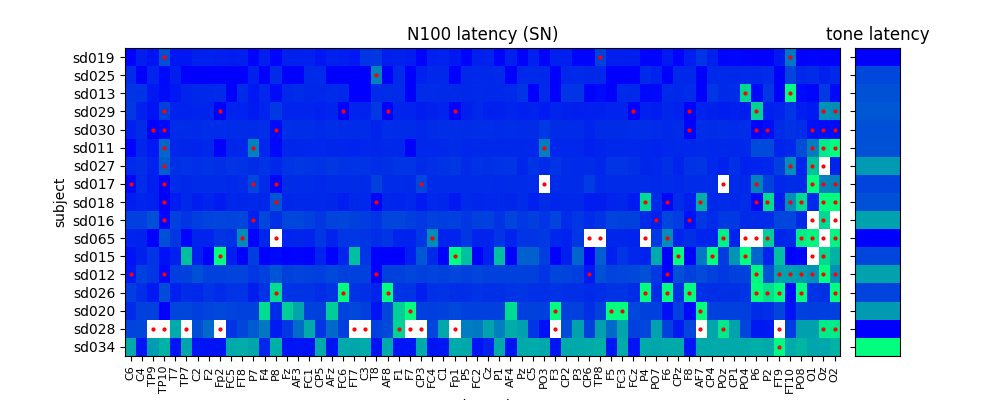

In [148]:
# the algorithm may identify wrong peaks for some channels if the signal is weak
# to fix that, for each subject and condition, we will look at the latencies of all
# channels, and remove channels with outlier latencies
peak_order = peaks.mean().sort_values().index
subject_order = peaks.loc['SN'].mean(axis=1).sort_values().index

f, (ax, axd) = plt.subplots(
    1, 2, figsize=(10, 4), width_ratios=[8, 0.5], sharey=True,
    gridspec_kw=dict(wspace=0.04)
)

# show the actual latencies
ax.imshow(
    peaks.loc['SN'][peak_order].loc[subject_order],
    aspect='auto', cmap='winter', vmin=0.15, vmax=0.6
)

# show the tone latency
axd.imshow(np.log(pd.DataFrame(delays).loc[subject_order]), aspect='auto', cmap='winter')

# show the channels that will be marked as outliers
mask = (
    (peaks.T < (peaks[peak_order].T.iloc[:40].mean()+peaks[peak_order].T.iloc[:40].std()*2)) &
    (peaks.T > (peaks[peak_order].T.iloc[:40].mean()-peaks[peak_order].T.iloc[:40].std()*2))
).T
mask_sn = mask.loc['SN']
_mask = ~mask_sn[peak_order].loc[subject_order].T
ax.scatter(*np.nonzero(_mask), c='r', s=4)

ax.set_xlabel('channel')
ax.set_ylabel('subject')
ax.set_xticks(range(64))
ax.set_xticklabels(peak_order, rotation=90, fontsize=8)
ax.set_yticks(range(peaks.shape[0]//2))
ax.set_yticklabels(subject_order)
axd.set_xticks([])
ax.set_title('N100 latency (SN)')
axd.set_title('tone latency');

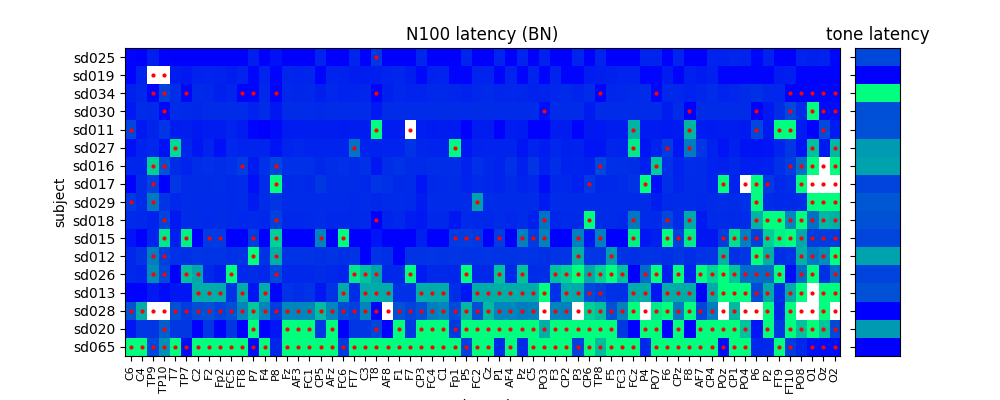

In [149]:
# the algorithm may identify wrong peaks for some channels if the signal is weak
# to fix that, for each subject and condition, we will look at the latencies of all
# channels, and remove channels with outlier latencies
peak_order = peaks.mean().sort_values().index
subject_order = peaks.loc['BN'].mean(axis=1).sort_values().index

f, (ax, axd) = plt.subplots(
    1, 2, figsize=(10, 4), width_ratios=[8, 0.5], sharey=True,
    gridspec_kw=dict(wspace=0.04)
)

# show the actual latencies
ax.imshow(
    peaks.loc['BN'][peak_order].loc[subject_order],
    aspect='auto', cmap='winter', vmin=0.15, vmax=0.6
)

# show the tone latency
axd.imshow(np.log(pd.DataFrame(delays).loc[subject_order]), aspect='auto', cmap='winter')

# show the channels that will be marked as outliers
mask_bn = peaks[mask].loc['BN']<0.25
_mask = ~mask_bn[peak_order].loc[subject_order].T
ax.scatter(*np.nonzero(_mask), c='r', s=4)

ax.set_xlabel('channel')
ax.set_ylabel('subject')
ax.set_xticks(range(64))
ax.set_xticklabels(peak_order, rotation=90, fontsize=8)
ax.set_yticks(range(peaks.shape[0]//2))
ax.set_yticklabels(subject_order)
axd.set_xticks([])
ax.set_title('N100 latency (BN)')
axd.set_title('tone latency');

In [172]:
peaks[mask].loc['SN'].T.iloc[:40].std()

sd011    0.017339
sd012    0.006281
sd013    0.034122
sd015    0.092299
sd016    0.012548
sd017    0.005223
sd018    0.009039
sd019    0.019448
sd020    0.094417
sd025    0.038315
sd026    0.013614
sd027    0.008439
sd028    0.077951
sd029    0.009370
sd030    0.005560
sd034    0.132451
sd065    0.013575
dtype: float64

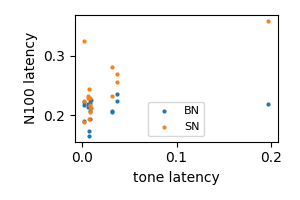

In [164]:
f, ax = plt.subplots(figsize=(3, 2), tight_layout=True)
ax.scatter(delays.loc[peaks.loc['BN'].index], peaks.loc['BN'][mask_bn].mean(axis=1), s=4, label='BN')
ax.scatter(delays.loc[peaks.loc['SN'].index], peaks.loc['SN'][mask_sn].mean(axis=1), s=4, label='SN')
ax.set_xlabel('tone latency')
ax.set_ylabel('N100 latency')
ax.legend(fontsize=8, loc=8);

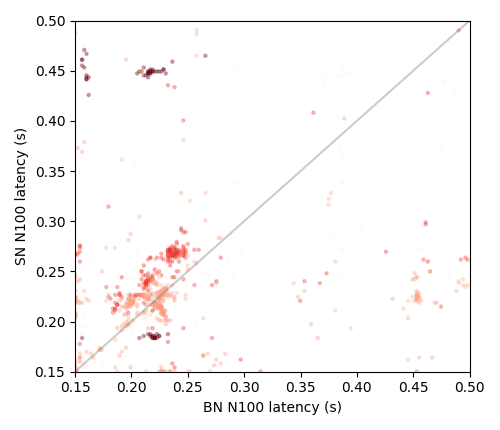

In [31]:
electrode = 'Pz'
f, ax = plt.subplots(figsize=(5, 4.3), tight_layout=True)
for electrode in peaks.BN.columns:
    ax.scatter(
        peaks['BN'][electrode], peaks['SN'][electrode],
        c=np.log(100*delays.loc[peaks.index]), cmap='Reds', s=5, alpha=0.3
    )
ax.plot([0.15, 0.5], [0.15, 0.5], c='gray', alpha=0.4)
ax.set_xlabel('BN N100 latency (s)')
ax.set_ylabel('SN N100 latency (s)')
ax.set_xlim(0.15, 0.5)
ax.set_ylim(0.15, 0.5);

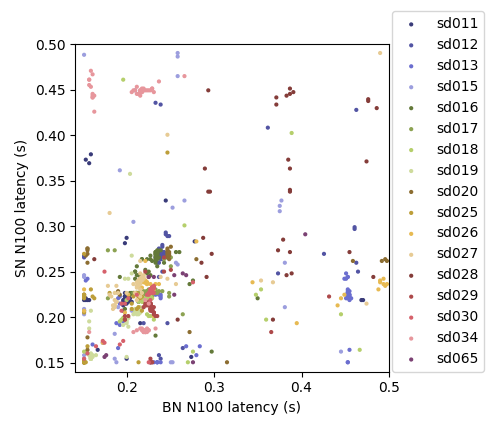

In [33]:
f, ax = plt.subplots(figsize=(5, 4.3), tight_layout=True)
for i, sub in enumerate(peaks.index):
    ax.scatter(peaks.loc[sub]['BN'], peaks.loc[sub]['SN'], label=sub, s=4, c=[i]*64, vmin=0, vmax=20, cmap='tab20b')
ax.legend(loc=(1.01, 0))
ax.set_xlabel('BN N100 latency (s)')
ax.set_ylabel('SN N100 latency (s)')
ax.set_xlim(0.14, 0.5)
ax.set_ylim(0.14, 0.5);